In [379]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA, NMF 

from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA, TruncatedSVD as SVD
import random


In [380]:
random.seed(101)

In [381]:
colors = "YlGnBu"

In [382]:
OHCO = ['book_title', 'chap_num', 'para_num', 'sent_num', 'token_num']
PARA = OHCO[:3]
CHAP = OHCO[:2]
BOOK = OHCO[:1]
BAG = BOOK

In [383]:
LIB = pd.read_csv("Corpus_Lib.csv")

In [384]:
LIB["label"]=LIB["book_title"]+LIB["author"]

In [385]:
TOKENS=pd.read_csv("Corpus_Tokens.csv")

In [386]:
DOCS = TOKENS[TOKENS.pos.str.match(r'^NNS?$')]\
    .groupby(BAG).term_str\
    .apply(lambda x: ' '.join(map(str,x)))\
    .to_frame()\
    .rename(columns={'term_str':'doc_str'})

In [387]:
from sklearn.feature_extraction import text

my_stop_words = list(text.ENGLISH_STOP_WORDS.union(['yes']))

In [388]:
count_engine = CountVectorizer(max_df=.9, min_df=10, stop_words=my_stop_words)
count_model = count_engine.fit_transform(DOCS.doc_str)
TERMS = count_engine.get_feature_names_out()
VOCAB = pd.DataFrame(index=TERMS)
VOCAB.index.name = 'term_str'
DTM = pd.DataFrame(count_model.toarray(), index=DOCS.index, columns=TERMS)
DTM

,abhorrence,abilities,ability,abode,absence,absent,abstraction,absurdity,abundance,accents,...,ye,yell,yellow,yesterdays,yielding,yonder,yore,youd,youve,zeal
book_title,,,,,,,,,,,,,,,,,,,,,
A Tale of Two Cities 1,0,0,1,0,0,0,1,0,0,0,...,0,0,2,0,0,0,0,0,0,0
A Tale of Two Cities 2,0,1,1,0,5,2,1,0,1,1,...,1,0,0,0,0,1,1,0,0,0
A Tale of Two Cities 3,1,0,0,1,3,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
Barnaby Rudge,2,2,1,1,10,1,2,2,2,5,...,10,3,2,1,0,12,4,12,1,5
Bleak House,1,4,4,4,14,3,4,1,1,1,...,5,2,0,0,1,5,1,5,4,0
David Copperfield,2,6,5,7,21,2,2,3,5,1,...,8,1,0,1,0,6,5,8,6,1
Dombey and Son,2,1,2,8,21,7,5,1,1,2,...,2,3,3,1,1,3,8,14,3,4
Great Expectations,4,3,1,1,6,1,1,0,1,0,...,1,2,1,0,1,5,4,5,3,2
Hard Times 1,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,5,1,0


In [389]:
n_topics = 8
max_iter = 100
n_top_terms = 9
TNAMES = [f"T{str(x).zfill(len(str(n_topics)))}" for x in range(n_topics)]

In [390]:
topic_engine = LDA(n_components=n_topics, max_iter=max_iter,random_state=101)
topic_model = topic_engine.fit_transform(count_model)

In [391]:
THETA = pd.DataFrame(topic_model, index=DOCS.index, columns=TNAMES)
THETA.columns.name = 'topic_id'
topic_summary = pd.DataFrame({
    'doc_weight_mean': THETA.mean(axis=0)
})
THETA.sample(10).T.style.background_gradient(cmap=colors, axis=None)

book_title,David Copperfield,Our Mutual Friend 4,Our Mutual Friend 3,Dombey and Son,Great Expectations,Bleak House,Our Mutual Friend 2,Pickwick Papers,A Tale of Two Cities 3,Little Dorrit 2
topic_id,,,,,,,,,,
T0,0.992478,0.000038,0.000037,0.967973,0.865904,0.978603,0.814493,0.367539,0.322031,0.908720
T1,0.000008,0.000038,0.000037,0.000007,0.000015,0.000008,0.000038,0.000007,0.000058,0.000017
T2,0.007022,0.000038,0.000037,0.000360,0.000886,0.000008,0.000038,0.571945,0.000058,0.000017
T3,0.000008,0.000038,0.000037,0.000007,0.000015,0.000008,0.000038,0.000007,0.000058,0.000017
T4,0.000462,0.000038,0.000037,0.031629,0.133133,0.021349,0.021672,0.060481,0.677621,0.091179
T5,0.000008,0.999736,0.000037,0.000007,0.000015,0.000008,0.000038,0.000007,0.000058,0.000017
T6,0.000008,0.000038,0.999743,0.000007,0.000015,0.000008,0.163645,0.000007,0.000058,0.000017
T7,0.000008,0.000038,0.000037,0.000007,0.000015,0.000008,0.000038,0.000007,0.000058,0.000017


In [392]:
PHI = pd.DataFrame(topic_engine.components_, columns=TERMS, index=TNAMES)
PHI.index.name = 'topic_id'
PHI.columns.name = 'term_str'
PHI.T.sample(10).T.style.background_gradient(cmap=colors, axis=None)

term_str,streams,transport,knocking,avowal,sights,presents,circulation,impossibility,outbreak,thorns
topic_id,,,,,,,,,,
T0,12.035462,21.191395,24.478210,20.311944,21.526658,21.928868,22.124191,44.028253,0.125367,12.616062
T1,5.079919,0.125007,8.108199,0.125194,0.125238,0.125440,0.125217,0.125114,0.125246,0.125367
T2,0.125170,4.373309,19.879990,7.556414,0.125342,0.125329,0.125196,0.125250,0.125398,0.125015
T3,0.125000,0.125000,0.125000,0.125131,0.125578,0.125000,0.125181,0.125000,0.125082,2.633335
T4,6.259449,2.810289,5.033602,0.125211,14.722184,0.125134,0.125215,0.125256,18.123907,0.125221
T5,0.125000,0.125000,1.124999,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,1.125000
T6,0.125000,1.125000,0.125000,2.506106,0.125000,1.320228,0.125000,1.221127,0.125000,0.125000
T7,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000


In [393]:
TOPICS = PHI.stack().groupby('topic_id')\
    .apply(lambda x: ' '.join(x.sort_values(ascending=False).head(n_top_terms).reset_index().term_str))\
    .to_frame('top_terms')
TOPICS

,top_terms
topic_id,
T0,aunt tea school parlour boat acquaintance hand...
T1,dwarf schoolmaster grandfather bachelor deligh...
T2,doctor wery maam uncle couple astonishment com...
T3,maam school facts thee shawl thou education st...
T4,prison prisoner lord village secretary prisone...
T5,dolls boat baby governor grass school stick ga...
T6,schoolmaster partner dolls doctor tea counting...
T7,lands robbery sent achievement forces amends s...


In [394]:
TOPICS['doc_weight_sum'] = THETA.sum()
TOPICS['doc_weight_mean'] = THETA.mean()
TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
TOPICS.sort_values('doc_weight_mean', ascending=False).style.background_gradient(cmap='YlGnBu', axis=0)

,top_terms,doc_weight_sum,doc_weight_mean,term_freq
topic_id,,,,
T0,aunt tea school parlour boat acquaintance handkerchief visit beauty,14.640085,0.636525,0.686313
T4,prison prisoner lord village secretary prisoners jail soldiers city,3.866075,0.168090,0.128314
T2,doctor wery maam uncle couple astonishment companion magistrate chaise,1.497176,0.065095,0.110281
T6,schoolmaster partner dolls doctor tea counting fog laugh cigar,1.164114,0.050614,0.022875
T5,dolls boat baby governor grass school stick gates schoolmaster,1.000499,0.043500,0.019605
T3,maam school facts thee shawl thou education statements chimneys,0.485046,0.021089,0.006054
T1,dwarf schoolmaster grandfather bachelor delight companion lodger baby landlord,0.346206,0.015052,0.024310
T7,lands robbery sent achievement forces amends sermon morality machine,0.000800,0.000035,0.002248


In [395]:
pca_engine = PCA(n_components=5)
DCM = pd.DataFrame(pca_engine.fit_transform(THETA), index=THETA.index)
DCM.columns = ['PC{}'.format(i) for i in DCM.columns]
DCM

,PC0,PC1,PC2,PC3,PC4
book_title,,,,,
A Tale of Two Cities 1,-0.405657,0.453673,-0.029171,-0.128660,-0.015522
A Tale of Two Cities 2,-0.242764,0.343627,-0.020373,-0.111282,-0.019416
A Tale of Two Cities 3,-0.391325,0.444320,-0.028419,-0.127261,-0.015979
Barnaby Rudge,-0.361958,0.395002,-0.024199,-0.072859,-0.018408
Bleak House,0.372954,-0.074059,0.013001,-0.044918,-0.033538
David Copperfield,0.390480,-0.090540,0.014361,-0.035077,-0.034198
Dombey and Son,0.360648,-0.065936,0.012355,-0.045847,-0.033271
Great Expectations,0.241936,0.014241,0.005951,-0.058050,-0.030562
Hard Times 1,0.043517,-0.068669,0.011144,0.002085,0.312312


In [396]:
COMPS = pd.DataFrame(pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_))
COMPS.columns = ["PC{}".format(i) for i in COMPS.columns]
COMPS.index = THETA.columns
COMPS.index.name = 'term_str'
COMPS.T

term_str,T0,T1,T2,T3,T4,T5,T6,T7
PC0,0.315347,-0.003601,-0.030674,0.004836,-0.100702,-0.095618,-0.089579,-8.559162e-06
PC1,0.004459,-0.000653,0.005061,-0.004363,0.196006,-0.090047,-0.110472,9.344472e-06
PC2,0.001265,0.000478,0.002532,0.001012,-0.012265,0.154774,-0.147796,-8.566084e-07
PC3,-0.024262,0.006582,0.145382,-0.000679,-0.044958,-0.043026,-0.039027,-1.076278e-05
PC4,-0.019369,0.032889,-0.020597,0.062690,-0.017167,-0.019489,-0.018968,1.138687e-05


In [397]:
def vis_pcs(DCM, a, b, label='book_title', hover_name='label'):
    return px.scatter(DCM, f"PC{a}", f"PC{b}", 
                    color=LIB[label], 
                    hover_name=LIB[hover_name], 
                    size=LIB['book_len'],
                    marginal_x='box', height=800)

In [398]:
def vis_loadings(COMPS, a=0, b=1, hover_name='term_str'):
    return px.scatter(COMPS.reset_index(), f"PC{a}", f"PC{b}", 
                      text='term_str', 
                      marginal_x='box',
                      size=topic_summary["doc_weight_mean"],
                      height=800)

In [399]:
vis_pcs(DCM, 0, 1)

In [400]:
vis_loadings(COMPS, 0, 1)

In [401]:
THETA

term_str,T0,T1,T2,T3,T4,T5,T6,T7
book_title,,,,,,,,
A Tale of Two Cities 1,0.309648,0.000133,0.000133,0.000133,0.689551,0.000133,0.000133,0.000133
A Tale of Two Cities 2,0.449668,0.000034,0.000034,0.000034,0.550127,0.000034,0.000034,0.000034
A Tale of Two Cities 3,0.322031,0.000058,0.000058,0.000058,0.677621,0.000058,0.000058,0.000058
Barnaby Rudge,0.339682,0.000009,0.045283,0.000009,0.614989,0.000009,0.000009,0.000009
Bleak House,0.978603,0.000008,0.000008,0.000008,0.021349,0.000008,0.000008,0.000008
David Copperfield,0.992478,0.000008,0.007022,0.000008,0.000462,0.000008,0.000008,0.000008
Dombey and Son,0.967973,0.000007,0.000360,0.000007,0.031629,0.000007,0.000007,0.000007
Great Expectations,0.865904,0.000015,0.000886,0.000015,0.133133,0.000015,0.000015,0.000015
Hard Times 1,0.607279,0.000080,0.000080,0.348039,0.044282,0.000080,0.000080,0.000080


In [402]:
THETAX = (
    THETA
    .reset_index()
    .merge(LIB, on='book_title', how='left')
    .set_index(['book_title',"author","book_len","n_chaps","label","avg_sent_len"])
)

In [403]:
THETAX

,,,,,,T0,T1,T2,T3,T4,T5,T6,T7
book_title,author,book_len,n_chaps,label,avg_sent_len,,,,,,,,
A Tale of Two Cities 1,Charles Dickens,17520,6,A Tale of Two Cities 1Charles Dickens,15.077453,0.309648,0.000133,0.000133,0.000133,0.689551,0.000133,0.000133,0.000133
A Tale of Two Cities 2,Charles Dickens,70973,24,A Tale of Two Cities 2Charles Dickens,13.998619,0.449668,0.000034,0.000034,0.000034,0.550127,0.000034,0.000034,0.000034
A Tale of Two Cities 3,Charles Dickens,48583,15,A Tale of Two Cities 3Charles Dickens,13.394817,0.322031,0.000058,0.000058,0.000058,0.677621,0.000058,0.000058,0.000058
Barnaby Rudge,Charles Dickens,255395,82,Barnaby RudgeCharles Dickens,16.299381,0.339682,0.000009,0.045283,0.000009,0.614989,0.000009,0.000009,0.000009
Bleak House,Charles Dickens,354643,67,Bleak HouseCharles Dickens,13.623872,0.978603,0.000008,0.000008,0.000008,0.021349,0.000008,0.000008,0.000008
David Copperfield,Charles Dickens,357805,64,David CopperfieldCharles Dickens,13.334513,0.992478,0.000008,0.007022,0.000008,0.000462,0.000008,0.000008,0.000008
Dombey and Son,Charles Dickens,356587,62,Dombey and SonCharles Dickens,15.899189,0.967973,0.000007,0.000360,0.000007,0.031629,0.000007,0.000007,0.000007
Great Expectations,Charles Dickens,186085,59,Great ExpectationsCharles Dickens,15.274153,0.865904,0.000015,0.000886,0.000015,0.133133,0.000015,0.000015,0.000015
Hard Times 1,Charles Dickens,37258,16,Hard Times 1Charles Dickens,12.502685,0.607279,0.000080,0.000080,0.348039,0.044282,0.000080,0.000080,0.000080


In [404]:
TOPIC_BOOK = THETAX.groupby('book_title').mean() #.T.join(TOPICS[['top_terms','doc_weight_sum','term_freq']])
TOPIC_BOOK.T.style.background_gradient(axis=0, cmap="YlGnBu")

book_title,A Tale of Two Cities 1,A Tale of Two Cities 2,A Tale of Two Cities 3,Barnaby Rudge,Bleak House,David Copperfield,Dombey and Son,Great Expectations,Hard Times 1,Hard Times 2,Hard Times 3,Little Dorrit 1,Little Dorrit 2,Martin Chuzzlewit,Nicholas Nickleby,Oliver Twist,Our Mutual Friend 1,Our Mutual Friend 2,Our Mutual Friend 3,Our Mutual Friend 4,Pickwick Papers,The Mystery of Edwin Drood,The Old Curiosity Shop
T0,0.309648,0.449668,0.322031,0.339682,0.978603,0.992478,0.967973,0.865904,0.607279,0.827636,0.707917,0.925958,0.908720,0.830557,0.676526,0.332485,0.967696,0.814493,0.000037,0.000038,0.367539,0.951134,0.496083
T1,0.000133,0.000034,0.000058,0.000009,0.000008,0.000008,0.000007,0.000015,0.000080,0.000081,0.000117,0.000016,0.000017,0.000007,0.010471,0.000015,0.000031,0.000038,0.000037,0.000038,0.000007,0.000027,0.334952
T2,0.000133,0.000034,0.000058,0.045283,0.000008,0.007022,0.000360,0.000886,0.000080,0.000081,0.060482,0.000016,0.000017,0.084417,0.216748,0.451588,0.000031,0.000038,0.000037,0.000038,0.571945,0.000027,0.057848
T3,0.000133,0.000034,0.000058,0.000009,0.000008,0.000008,0.000007,0.000015,0.348039,0.082965,0.053519,0.000016,0.000017,0.000007,0.000007,0.000015,0.000031,0.000038,0.000037,0.000038,0.000007,0.000026,0.000010
T4,0.689551,0.550127,0.677621,0.614989,0.021349,0.000462,0.031629,0.133133,0.044282,0.088992,0.177613,0.073949,0.091179,0.084990,0.096225,0.215854,0.032119,0.021672,0.000037,0.000038,0.060481,0.048707,0.111076
T5,0.000133,0.000034,0.000058,0.000009,0.000008,0.000008,0.000007,0.000015,0.000080,0.000081,0.000117,0.000016,0.000017,0.000007,0.000007,0.000015,0.000031,0.000038,0.000037,0.999736,0.000007,0.000026,0.000010
T6,0.000133,0.000034,0.000058,0.000009,0.000008,0.000008,0.000007,0.000015,0.000080,0.000081,0.000117,0.000016,0.000017,0.000007,0.000007,0.000015,0.000031,0.163645,0.999743,0.000038,0.000007,0.000026,0.000010
T7,0.000133,0.000034,0.000058,0.000009,0.000008,0.000008,0.000007,0.000015,0.000080,0.000081,0.000117,0.000015,0.000017,0.000007,0.000007,0.000015,0.000031,0.000038,0.000037,0.000038,0.000007,0.000026,0.000010


## RIFF 1

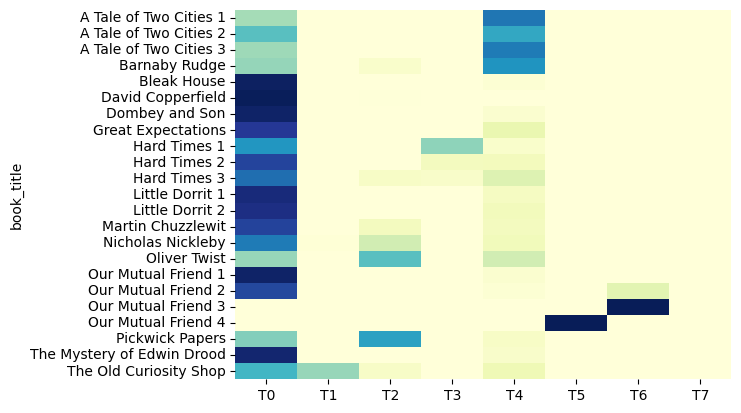

In [405]:
sns.heatmap(TOPIC_BOOK, cmap="YlGnBu", cbar=None)
plt.show()

In [406]:
TOPICS.to_csv('TOPICS.csv')
PHI.to_csv('PHI.csv')
THETA.to_csv('THETA.csv')